# Exploração temporal - Diesel (ANP), preço REAL (deflacionado pelo IPCA)

Mesmas análises de `02_exploratory_time_series_diesel.ipynb`, mas usando `valor_de_venda_real` (preço deflacionado pelo IPCA, base: último mês disponível na série do IPCA no lugar do preço nominal em todas as consultas e gráficos.

O objetivo é separar inflação geral (perda de poder de compra do real) de variação real do preço do combustível - o que o notebook nominal mistura, especialmente nas séries de longo prazo (2004-2026) e nas variações YoY/MoM.

In [1]:
import sys
from pathlib import Path

PROJECT_ROOT = Path.cwd().parent if (Path.cwd().parent / "pyproject.toml").exists() else Path.cwd()
if str(PROJECT_ROOT) not in sys.path:
    sys.path.insert(0, str(PROJECT_ROOT))

import duckdb
import pandas as pd
import matplotlib.pyplot as plt

from src.config import HF_REPO_ID

In [2]:
# Estilo dos gráficos - paleta consistente, pensada pra ficar legível em print de slide
import numpy as np

PALETTE = {
    "surface": "#fcfcfb",
    "text_primary": "#0b0b0b",
    "text_secondary": "#52514e",
    "muted": "#898781",
    "grid": "#e1e0d9",
    "baseline": "#c3c2b7",
    # ordem fixa - identidade de série, nunca reordenada por rank/filtro
    "categorical": [
        "#2a78d6",  # 1 azul
        "#eb6834",  # 2 laranja
        "#1baf7a",  # 3 água
        "#eda100",  # 4 amarelo
        "#e87ba4",  # 5 magenta
        "#008300",  # 6 verde
        "#4a3aa7",  # 7 violeta
        "#e34948",  # 8 vermelho
    ],
    # rampa sequencial (azul, claro->escuro) para magnitude/ranking
    "sequential": [
        "#cde2fb", "#9ec5f4", "#6da7ec", "#3987e5",
        "#256abf", "#184f95", "#0d366b",
    ],
}

# identidade fixa por região/produto - a cor de uma série nunca muda entre
# gráficos, nem quando o filtro/ordenação muda
REGION_COLORS = {
    "N": PALETTE["categorical"][0],
    "NE": PALETTE["categorical"][1],
    "CO": PALETTE["categorical"][2],
    "SE": PALETTE["categorical"][3],
    "S": PALETTE["categorical"][4],
}
PRODUCT_COLORS = {
    "DIESEL": PALETTE["categorical"][0],
    "DIESEL S10": PALETTE["categorical"][1],
    "DIESEL S50": PALETTE["categorical"][2],
}


def sequential_by_rank(n: int) -> list[str]:
    """n cores da rampa sequencial, da mais escura (rank 1) pra mais clara."""
    ramp = PALETTE["sequential"][::-1]
    idx = np.linspace(0, len(ramp) - 1, n)
    return [ramp[round(i)] for i in idx]


plt.rcParams.update({
    "figure.facecolor": PALETTE["surface"],
    "figure.dpi": 150,
    "savefig.dpi": 200,
    "savefig.facecolor": PALETTE["surface"],
    "axes.facecolor": PALETTE["surface"],
    "axes.edgecolor": PALETTE["baseline"],
    "axes.labelcolor": PALETTE["text_secondary"],
    "axes.titlecolor": PALETTE["text_primary"],
    "axes.titleweight": "bold",
    "axes.titlesize": 13,
    "axes.titlepad": 12,
    "axes.grid": True,
    "axes.grid.axis": "y",
    "axes.spines.top": False,
    "axes.spines.right": False,
    "axes.spines.left": False,
    "axes.prop_cycle": plt.cycler(color=PALETTE["categorical"]),
    "grid.color": PALETTE["grid"],
    "grid.linewidth": 0.8,
    "text.color": PALETTE["text_primary"],
    "xtick.color": PALETTE["muted"],
    "ytick.color": PALETTE["muted"],
    "xtick.labelsize": 10,
    "ytick.labelsize": 10,
    "font.size": 11,
    "font.family": "sans-serif",
    "legend.frameon": False,
    "legend.fontsize": 10,
    "lines.linewidth": 2,
    "lines.markersize": 4,
})

In [3]:
# lido direto do dataset público do time no Hugging Face Hub, sem precisar rodar o pipeline localmente
# diesel_deflacionado.parquet = diesel.parquet + valor_de_venda_real (deflacionado pelo IPCA)
df_data = pd.read_parquet(f"hf://datasets/{HF_REPO_ID}/interim/diesel/diesel_deflacionado.parquet")

# a partir daqui todas as análises usam o preço REAL (deflacionado) no lugar do nominal -
# descarta o nominal e renomeia valor_de_venda_real -> valor_de_venda, mantendo
# o resto do notebook idêntico em estrutura ao 02_exploratory_time_series_diesel.ipynb
df_data = df_data.drop(columns=["valor_de_venda"]).rename(columns={"valor_de_venda_real": "valor_de_venda"})

In [4]:
df_data

,regiao_sigla,estado_sigla,municipio,revenda,cnpj_da_revenda,nome_da_rua,numero_da_rua,complemento,bairro,cep,produto,data_da_coleta,valor_de_compra,unidade_de_medida,bandeira,file_name,valor_de_venda
0,SE,SP,SOROCABA,COMPETRO COMERCIO E DISTRIBUICAO DE DERIVADOS ...,00.003.188/0001-21,RUA HUMBERTO DE CAMPOS,306,NaN,JARDIM ZULMIRA,18061-000,DIESEL S10,2023-01-03,NaN,R$ / litro,BRANCA,Preços semestrais - AUTOMOTIVOS_2023.01.csv,7.283258
1,NE,AL,ARAPIRACA,COMERCIAL DE COMBUSTIVEIS E LUBRIFICANTES VITA...,02.817.655/0001-82,RODOVIA AL 220 - KM 06,S/N,NaN,PLANALTO,57308-000,DIESEL,2023-01-02,NaN,R$ / litro,VIBRA ENERGIA,Preços semestrais - AUTOMOTIVOS_2023.01.csv,7.611650
2,NE,AL,ARAPIRACA,IBN PINTO E SILVA & CIA LTDA,01.242.690/0001-58,RODOVIA AL-110,678,KM 70,CANAFISTULA,57302-802,DIESEL,2023-01-02,NaN,R$ / litro,IPIRANGA,Preços semestrais - AUTOMOTIVOS_2023.01.csv,8.080781
3,NE,AL,ARAPIRACA,IBN PINTO E SILVA & CIA LTDA,01.242.690/0002-39,"AVENIDA EMIDIO DE LIMA,",23,NaN,JARDIM ESPERANCA,57304-820,DIESEL,2023-01-02,NaN,R$ / litro,IPIRANGA,Preços semestrais - AUTOMOTIVOS_2023.01.csv,8.198064
4,N,AM,PARINTINS,F.J. COMERCIO DE COMBUSTIVEIS LTDA,09.368.602/0001-70,RUA PARAIBA,41,CONJ MACURANY,RAIMUNDO MUNIZ,69151-456,DIESEL S10,2023-01-05,NaN,R$ / litro,BRANCA,Preços semestrais - AUTOMOTIVOS_2023.01.csv,9.828294
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
8196136,SE,MG,PASSOS,POSTO OASIS PASSOS LTDA,21.628.904/0001-36,RUA DOUTOR CARVALHO,222,NaN,CENTRO,37900-000,DIESEL,2013-02-20,NaN,R$ / litro,IPIRANGA,ca-2013-01.csv,4.738348
8196137,SE,MG,PASSOS,COLEGIO AUTO POSTO LTDA,04.083.147/0001-43,AVENIDA DOS EXPEDICIONARIOS,917,NaN,JARDIM COLEGIO DE PASSOS,37900-000,DIESEL,2013-02-20,NaN,R$ / litro,BRANCA,ca-2013-01.csv,4.278922
8196138,SE,MG,PASSOS,POSTO BJ LTDA,03.913.321/0001-75,RODOVIA MG 050,586,NaN,NOVO HORIZONTE,37901-300,DIESEL,2013-02-20,1.999,R$ / litro,BRANCA,ca-2013-01.csv,4.698670
8196139,SE,MG,PASSOS,POSTO BJ LTDA,03.913.321/0001-75,RODOVIA MG 050,586,NaN,NOVO HORIZONTE,37901-300,DIESEL S10,2013-02-20,2.160,R$ / litro,BRANCA,ca-2013-01.csv,5.032798


8.196.141 linhas, 17 colunas, já filtradas para `produto` contendo "DIESEL" (feito no `clean.py`). Cada linha é uma coleta de preço em um posto revendedor específico (não um preço nacional agregado) - os agregados por período/região nas próximas células são todos calculados a partir desses registros individuais.

In [5]:
df_data.info()

<class 'pandas.DataFrame'>
RangeIndex: 8196141 entries, 0 to 8196140
Data columns (total 17 columns):
 #   Column             Dtype         
---  ------             -----         
 0   regiao_sigla       str           
 1   estado_sigla       str           
 2   municipio          str           
 3   revenda            str           
 4   cnpj_da_revenda    str           
 5   nome_da_rua        str           
 6   numero_da_rua      str           
 7   complemento        str           
 8   bairro             str           
 9   cep                str           
 10  produto            str           
 11  data_da_coleta     datetime64[us]
 12  valor_de_compra    float64       
 13  unidade_de_medida  str           
 14  bandeira           str           
 15  file_name          str           
 16  valor_de_venda     float64       
dtypes: datetime64[us](1), float64(2), str(14)
memory usage: 2.2 GB


# Qualidade dos dados - valores nulos

In [6]:
columns = df_data.columns.tolist()

null_counts_sql = ", ".join(f'sum(case when "{col}" is null then 1 else 0 end) as "{col}"' for col in columns)
nulls = duckdb.sql(f'select {null_counts_sql} from df_data').df().T
nulls.columns = ["valores_ausentes"]
nulls["pct_ausentes"] = (nulls["valores_ausentes"] / len(df_data) * 100).round(2)
nulls.sort_values("valores_ausentes", ascending=False)

,valores_ausentes,pct_ausentes
complemento,5894804.0,71.92
valor_de_compra,4885349.0,59.61
bairro,26240.0,0.32
numero_da_rua,4172.0,0.05
produto,0.0,0.00
file_name,0.0,0.00
bandeira,0.0,0.00
unidade_de_medida,0.0,0.00
data_da_coleta,0.0,0.00
regiao_sigla,0.0,0.00


Todas as colunas usadas nas análises deste notebook (`valor_de_venda`, `produto`, `estado_sigla`/`regiao_sigla`, `bandeira`, `data_da_coleta`) têm **0% de nulos**. Os únicos nulos relevantes estão em colunas que não usamos em nenhuma análise.

In [7]:
valor_venda_nulls_por_ano = duckdb.sql("""
    select
        year(data_da_coleta) as ano,
        count(*) as linhas,
        sum(case when valor_de_venda is null then 1 else 0 end) as valor_venda_nulo,
        round(sum(case when valor_de_venda is null then 1 else 0 end) * 100.0 / count(*), 2) as pct_nulo
    from df_data
    group by 1
    order by 1
""").df()
valor_venda_nulls_por_ano

,ano,linhas,valor_venda_nulo,pct_nulo
0,2004,359036,0.0,0.0
1,2005,493445,0.0,0.0
2,2006,481981,0.0,0.0
3,2007,373529,0.0,0.0
4,2008,391313,0.0,0.0
5,2009,333700,0.0,0.0
6,2010,377283,0.0,0.0
7,2011,386446,0.0,0.0
8,2012,424700,0.0,0.0
9,2013,459923,0.0,0.0


Confirmado: `valor_de_venda` tem 0% de nulos em todos os 22 anos, do primeiro (2004) ao último (2026). 

# Cobertura Temporal

In [8]:
date_range = duckdb.sql(f"""
    select min(data_da_coleta) as data_min, max(data_da_coleta) as data_max
    from df_data
""").df()

date_range

,data_min,data_max
0,2004-05-10,2026-06-30


Cobertura de ~22 anos (2004-05 a 2026-06) — janela longa o suficiente para capturar múltiplos ciclos de safra e pelo menos três regimes distintos de precificação:

- Pré/pós paridade de importação (2016)
- Congelamento de preços (2021)
- Reforma do ICMS monofásico (2022-2023)

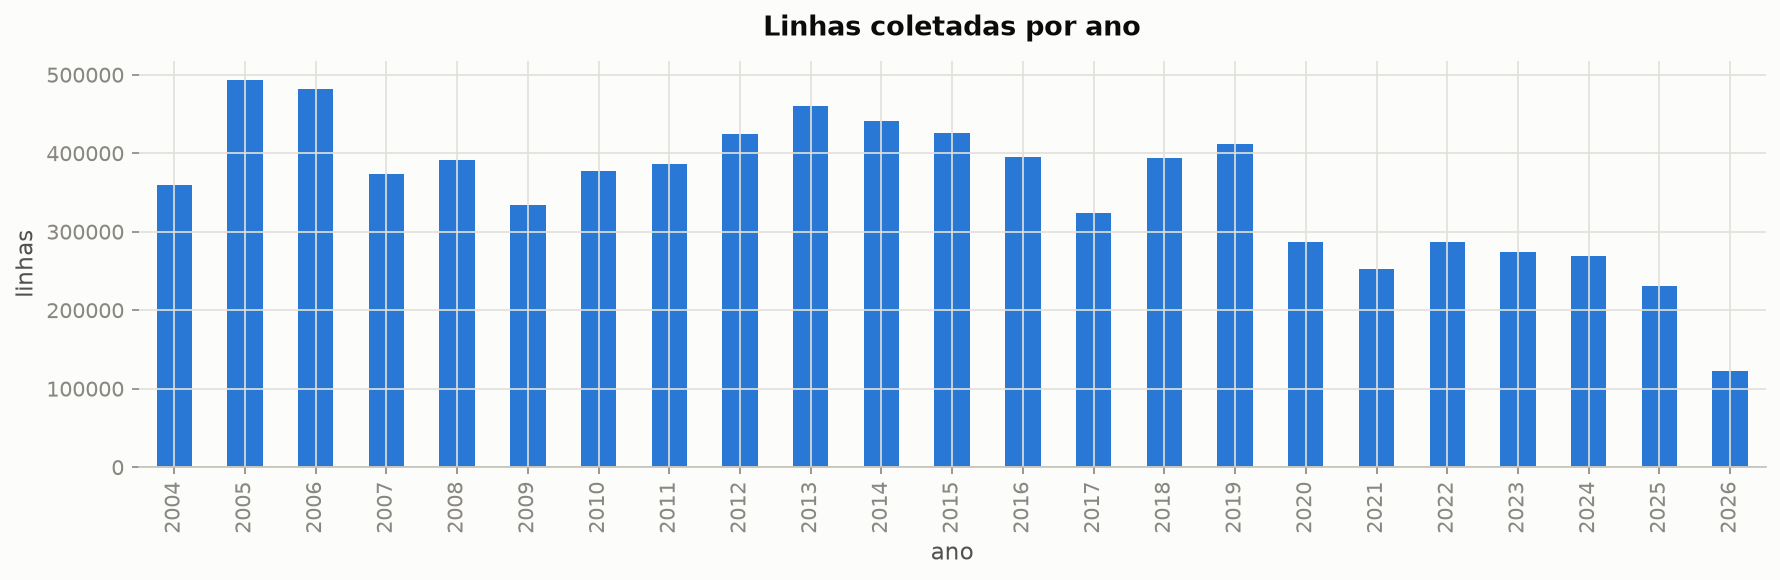

In [9]:
rows_per_year = duckdb.sql(f"""
    select year(data_da_coleta) as ano, count(*) as linhas
    from df_data
    group by 1
    order by 1
""").df()

rows_per_year.plot(
    x="ano", y="linhas", kind="bar", figsize=(12, 4), legend=False,
    title="Linhas coletadas por ano", color=PALETTE["categorical"][0],
)
plt.ylabel("linhas")
plt.tight_layout()
plt.show()

Volume de coleta não é constante:

- **Pico:** 2005-2006 (~490 mil linhas/ano).
- **Queda gradual** a partir de 2017.
- **Patamar mais baixo** a partir de 2020 (~250-290 mil/ano) — provavelmente reflete mudança na quantidade de postos/revendas reportando ou na periodicidade de coleta da ANP ao longo dos anos, não uma mudança real no mercado.
- **2026** aparece bem menor porque a série vai só até junho desse ano (ano parcial).

Vale ter isso em mente ao comparar estatísticas de períodos diferentes: anos com menos coletas têm médias mais sensíveis a outliers.

# Produtos

In [10]:
by_product = duckdb.sql(f"""
    select coalesce(produto, '(nulo)') as produto, count(*) as linhas
    from df_data
    group by 1
    order by 2 desc
""").df()
by_product

,produto,linhas
0,DIESEL,5697313
1,DIESEL S10,2454333
2,DIESEL S50,44495


- **DIESEL (comum):** 5,7M linhas (70%) — domina a série.
- **DIESEL S10:** 2,45M linhas (30%).
- **DIESEL S50:** 44 mil linhas (~0,5%) — residual.

S50 foi uma variante de transição (menor teor de enxofre que o comum, anterior ao S10) vendida só num período curto — por isso o volume tão baixo. Nas análises abaixo, o S50 tende a ter pouco peso estatístico e a aparecer só numa fatia do eixo temporal.

# Preço de venda - estatísticas por tipo de diesel


In [11]:
diesel_stats = duckdb.sql(f"""
    select
        produto,
        count(*) as n,
        round(avg(valor_de_venda), 3) as preco_medio,
        round(median(valor_de_venda), 3) as preco_mediano,
        round(stddev(valor_de_venda), 3) as desvio_padrao,
        round(min(valor_de_venda), 3) as preco_min,
        round(max(valor_de_venda), 3) as preco_max
    from df_data
    group by 1
    order by 1
""").df()
diesel_stats

,produto,n,preco_medio,preco_mediano,desvio_padrao,preco_min,preco_max
0,DIESEL,5697313,5.246,5.128,0.698,2.360,10.741
1,DIESEL S10,2454333,5.820,5.467,1.008,3.529,11.378
2,DIESEL S50,44495,4.711,4.671,0.246,3.505,6.251


Em termos reais o gap entre variantes encolhe bastante:

- S10: R$5,82
- DIESEL comum: R$5,25
- Razão: **~1,11x** (contra ~1,66x nominal — R$4,25 vs R$2,56)

Isso confirma a suspeita do notebook nominal: grande parte daquela diferença era viés de período (S10 concentrado em anos mais recentes e caros em termos nominais), não uma diferença real e estrutural entre os produtos.

Ainda sobra um gap real de ~R$0,57/litro — parte do efeito é produto de fato (S10 é mais caro de produzir/importar), só que bem menor do que a comparação nominal bruta sugeria.

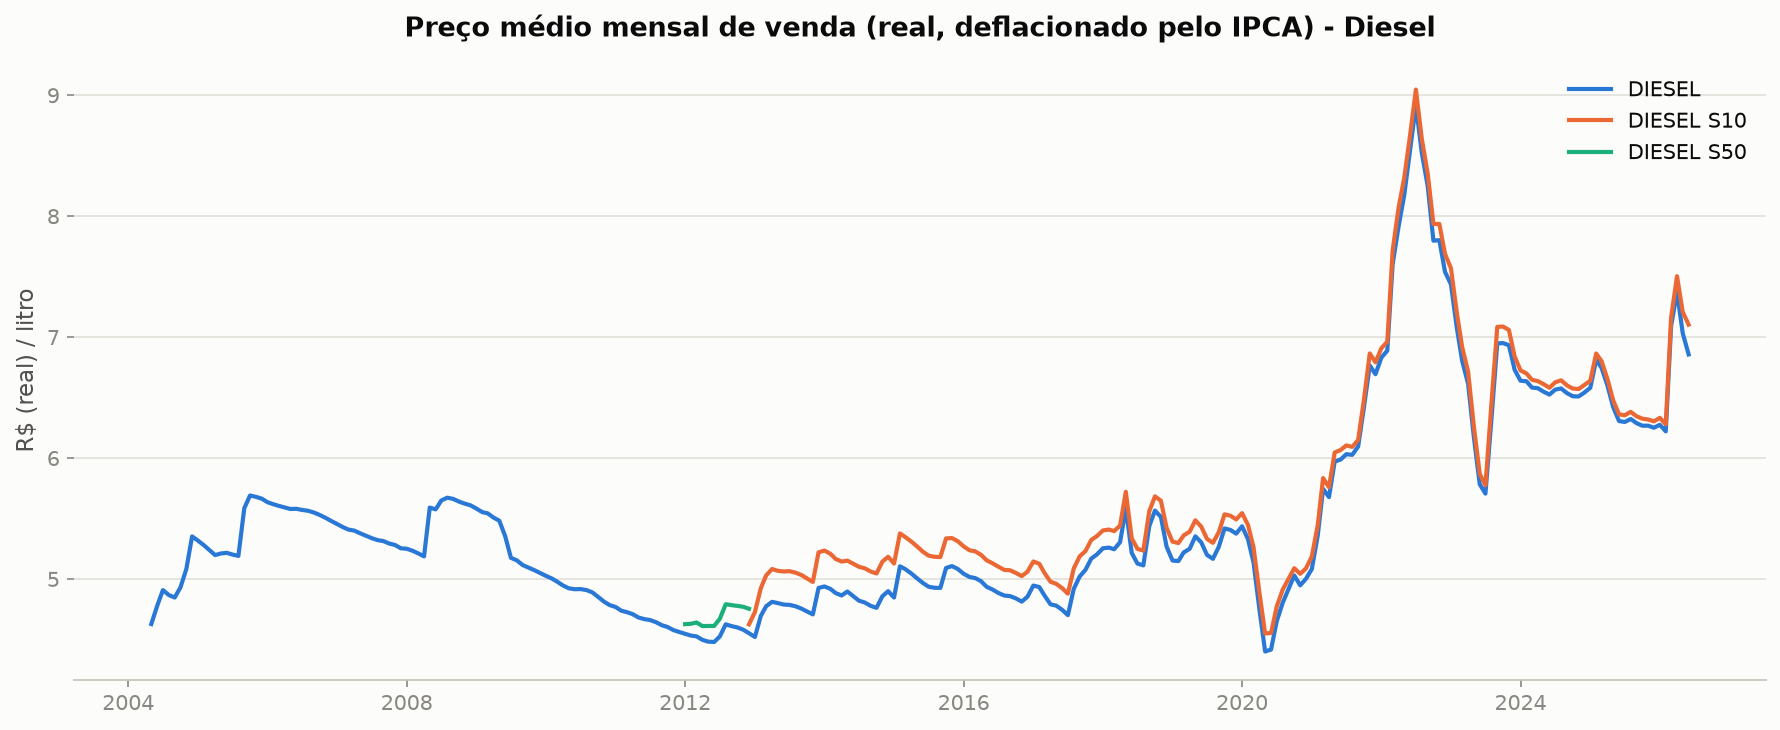

In [12]:
monthly_price = duckdb.sql(f"""
    select
        date_trunc('month', data_da_coleta) as mes,
        produto,
        avg(valor_de_venda) as preco_medio
    from df_data
    group by 1, 2
    order by 1
""").df()

fig, ax = plt.subplots(figsize=(12, 5))
for produto, group in monthly_price.groupby("produto"):
    ax.plot(group["mes"], group["preco_medio"], label=produto, color=PRODUCT_COLORS[produto])
ax.set_title("Preço médio mensal de venda (real, deflacionado pelo IPCA) - Diesel")
ax.set_ylabel("R$ (real) / litro")
ax.legend()
plt.tight_layout()
plt.show()

DIESEL e DIESEL S10 seguem coladas a partir de ~2013 — mesma leitura do notebook nominal, a diferença de médias da tabela anterior era mesmo efeito de período.

Mas a forma da curva conjunta muda bastante ao deflacionar:

- **2004-2020:** preço real oscila praticamente estável entre **R$4,5 e R$5,7**, com mínimo em maio/2020 (~R$4,49, fundo do choque de demanda da pandemia). Boa parte da "rampa forte 2016-2022" do nominal era só inflação geral acumulando, não o diesel ficando mais caro de fato.
- **2021-2022:** alta real de verdade — recuperação pós-pandemia + pressão de commodities, acelerando com o choque internacional de 2022 até um **pico de R$9,00/litro em julho/2022** (quase o dobro do patamar histórico pré-2021).
- **2023:** desaba com a reforma do ICMS monofásico até um **mínimo de R$5,75 em julho/2023**.
- **2023-2026:** se estabiliza num patamar novo e permanentemente mais alto (**R$6,3-7,5**) que a faixa 2004-2020.

O choque de 2021-2023 é o evento dominante da série real; tudo antes dele é ruído em torno de um nível praticamente constante.

# Preço de venda - estatísticas por estado e região do Brasil


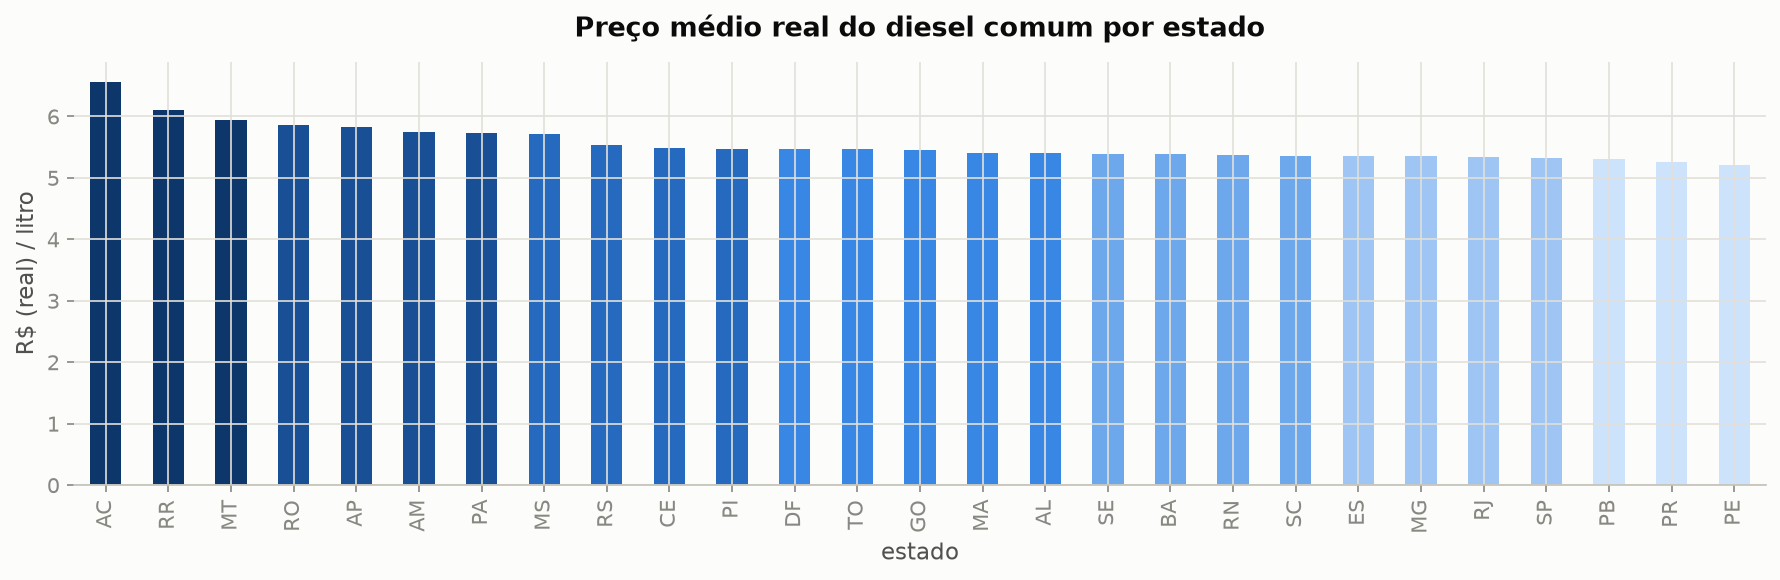

In [13]:
by_state = duckdb.sql(f"""
    select 
        estado_sigla as estado, 
        avg(valor_de_venda) as preco_medio, 
        count(*) as n
    from df_data
    group by 1
    order by 2 desc
""").df()

by_state.plot(
    x="estado", y="preco_medio", kind="bar", figsize=(12, 4), legend=False,
    title="Preço médio real do diesel comum por estado",
    color=sequential_by_rank(len(by_state)),
)
plt.ylabel("R$ (real) / litro")
plt.tight_layout()
plt.show()

O ranking se mantém idêntico ao nominal:

- **Mais caro:** AC (Acre), com folga (~R$6,57), seguido por RR, MT, RO, AP, AM — todos Norte/Centro-Oeste, distantes das refinarias e portos do litoral.
- **Mais barato:** PE, fechando a lista (~R$5,21).

O gap absoluto entre os extremos cresce em termos reais (~R$1,35 vs ~R$1,05 nominal), simplesmente porque a base de deflação (mês mais recente) está num patamar de preço mais alto que a média histórica da série. Mas a ordem e a lógica (custo de frete/logística cresce com a distância da origem do combustível) são as mesmas — o que reforça que esse padrão espacial não é um artefato de inflação, é estrutural.

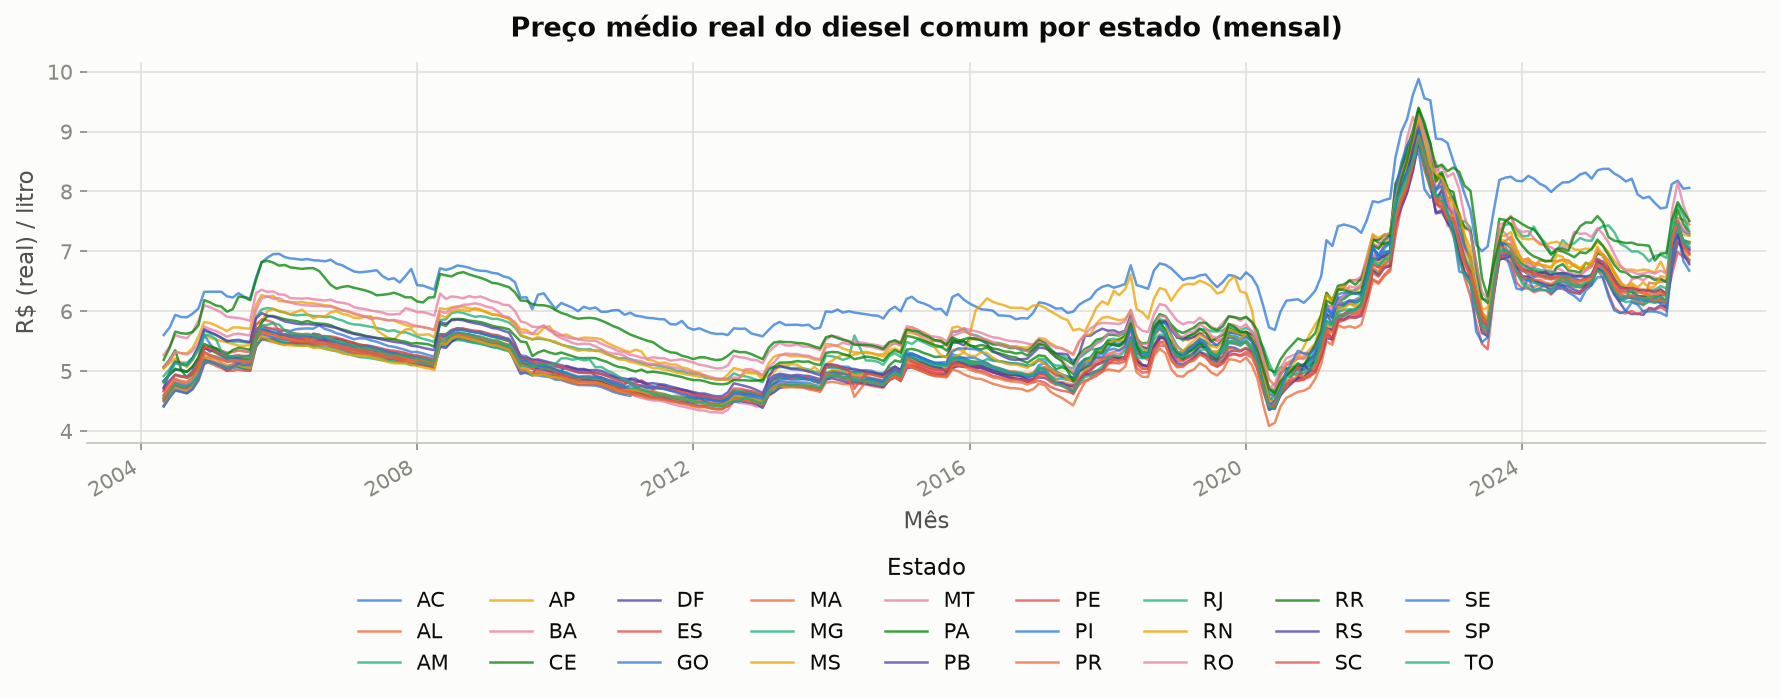

In [14]:
by_state_month = duckdb.sql(f"""
    select
        date_trunc('month', data_da_coleta) as mes,
        estado_sigla as regiao,
        avg(valor_de_venda) as preco_medio,
        count(*) as n
    from df_data
    group by 1, 2
    order by 1, 2
""").df()

pivot = by_state_month.pivot(index="mes", columns="regiao", values="preco_medio")

# 27 séries excedem qualquer paleta categórica acessível - usamos baixa opacidade
# e sem marcador pra reduzir a poluição visual do "espaguete"; a leitura aqui é de
# padrão de conjunto (ex. AC acima do grupo), não de série individual
pivot.plot(
    kind="line", figsize=(12, 5), linewidth=1.2, alpha=0.75,
    title="Preço médio real do diesel comum por estado (mensal)",
)
plt.ylabel("R$ (real) / litro")
plt.xlabel("Mês")
plt.legend(title="Estado", loc="upper center", bbox_to_anchor=(0.5, -0.25), ncol=9)
plt.tight_layout()
plt.show()

Com 27 séries sobrepostas fica difícil distinguir estado a estado, mas dá pra confirmar visualmente que o AC (linha azul-escura) se mantém acima do conjunto ao longo de praticamente toda a série — igual ao nominal, o ranking do gráfico de barras anterior não é um efeito de médio prazo isolado, é persistente desde o início da série, mesmo depois de remover a inflação geral.

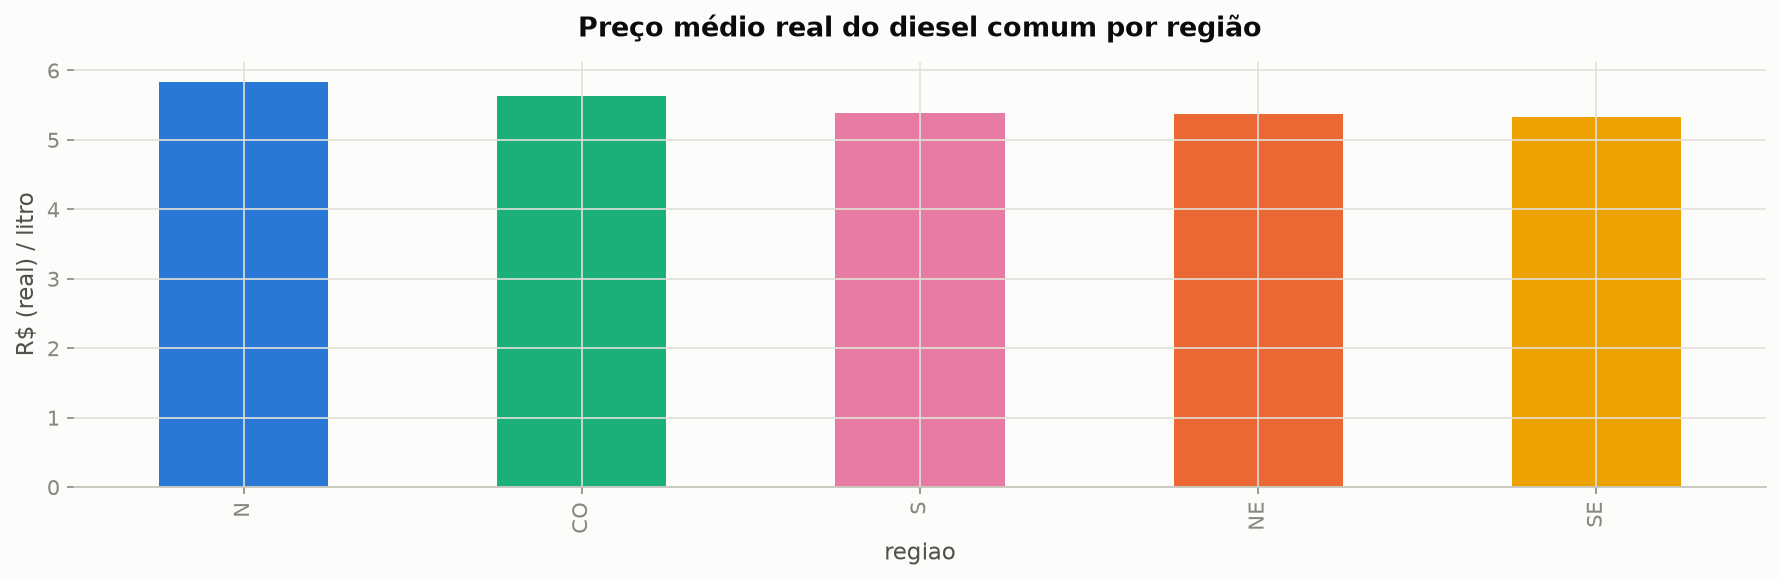

In [15]:
by_region = duckdb.sql(f"""
    select 
        regiao_sigla as regiao, 
        avg(valor_de_venda) as preco_medio, 
        count(*) as n
    from df_data
    group by 1
    order by 2 desc
""").df()

by_region.plot(
    x="regiao", y="preco_medio", kind="bar", figsize=(12, 4), legend=False,
    title="Preço médio real do diesel comum por região",
    color=[REGION_COLORS[r] for r in by_region["regiao"]],
)
plt.ylabel("R$ (real) / litro")
plt.tight_layout()
plt.show()

Agregando por região o padrão se mantém — **N mais caro** (R$5,84), **SE mais barato** (R$5,33) — mas a amplitude encolhe bastante:

- Por região (N vs SE): **~R$0,50**
- Por estado (AC vs PE): **~R$1,35**

Mesma lógica do nominal: região é uma média de estados heterogêneos (o Norte mistura AC/RO, caros, com AM/RR, mais moderados), então agregar nesse nível esconde parte da variação que interessa se o objetivo é usar o diesel como proxy de custo de frete local.

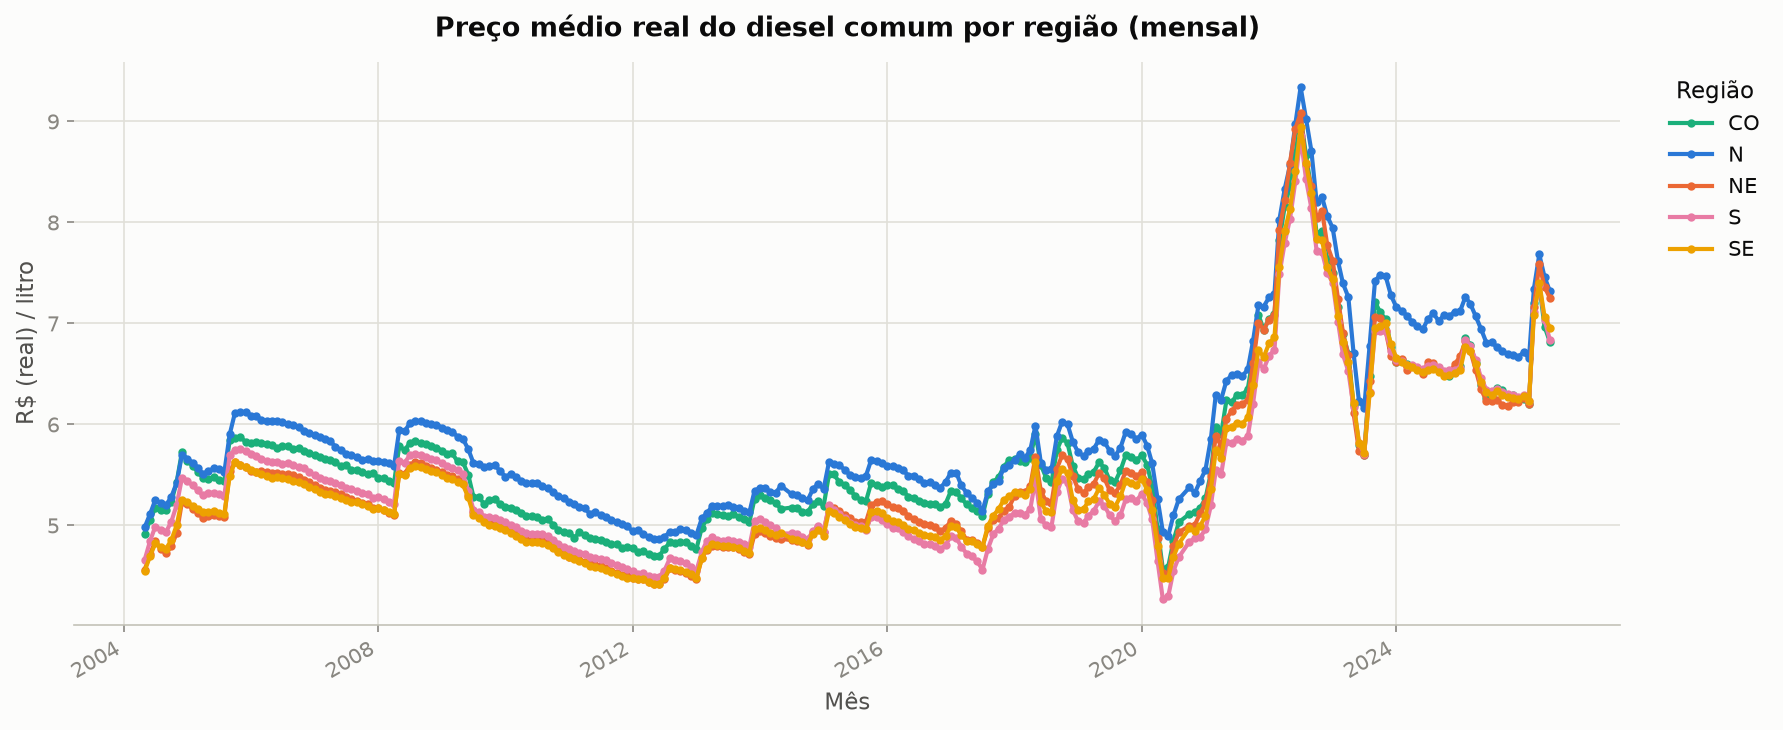

In [16]:
by_region_month = duckdb.sql(f"""
    select
        date_trunc('month', data_da_coleta) as mes,
        regiao_sigla as regiao,
        avg(valor_de_venda) as preco_medio,
        count(*) as n
    from df_data
    group by 1, 2
    order by 1, 2
""").df()

pivot = by_region_month.pivot(index="mes", columns="regiao", values="preco_medio")

pivot.plot(
    kind="line", figsize=(12, 5), marker="o", markersize=3,
    title="Preço médio real do diesel comum por região (mensal)",
    color=[REGION_COLORS[r] for r in pivot.columns],
)
plt.ylabel("R$ (real) / litro")
plt.xlabel("Mês")
plt.legend(title="Região", bbox_to_anchor=(1.02, 1), loc="upper left")
plt.tight_layout()
plt.show()


A região Norte (azul) fica acima das demais durante praticamente toda a série (gap médio N-SE de ~R$0,47/litro), mas a leitura sobre onde o gap se alarga muda em termos reais:

- **Pico do gap:** não é 2022 (~R$0,39-0,47) — é **abril/2023** (~R$0,64), no meio da turbulência da reforma do ICMS monofásico.
- **Ponto mais estreito:** **março/2026** (~R$0,26), o mês mais recente da série.

Ou seja, ao contrário do que a leitura nominal sugeria (choques nacionais amplificados no Norte nos picos de preço), em termos reais o Norte se aproximou do resto do país nos meses mais recentes, e o maior descolamento aconteceu num momento de queda abrupta de preço (2023), não de alta.

# Dispersão de preços por estado

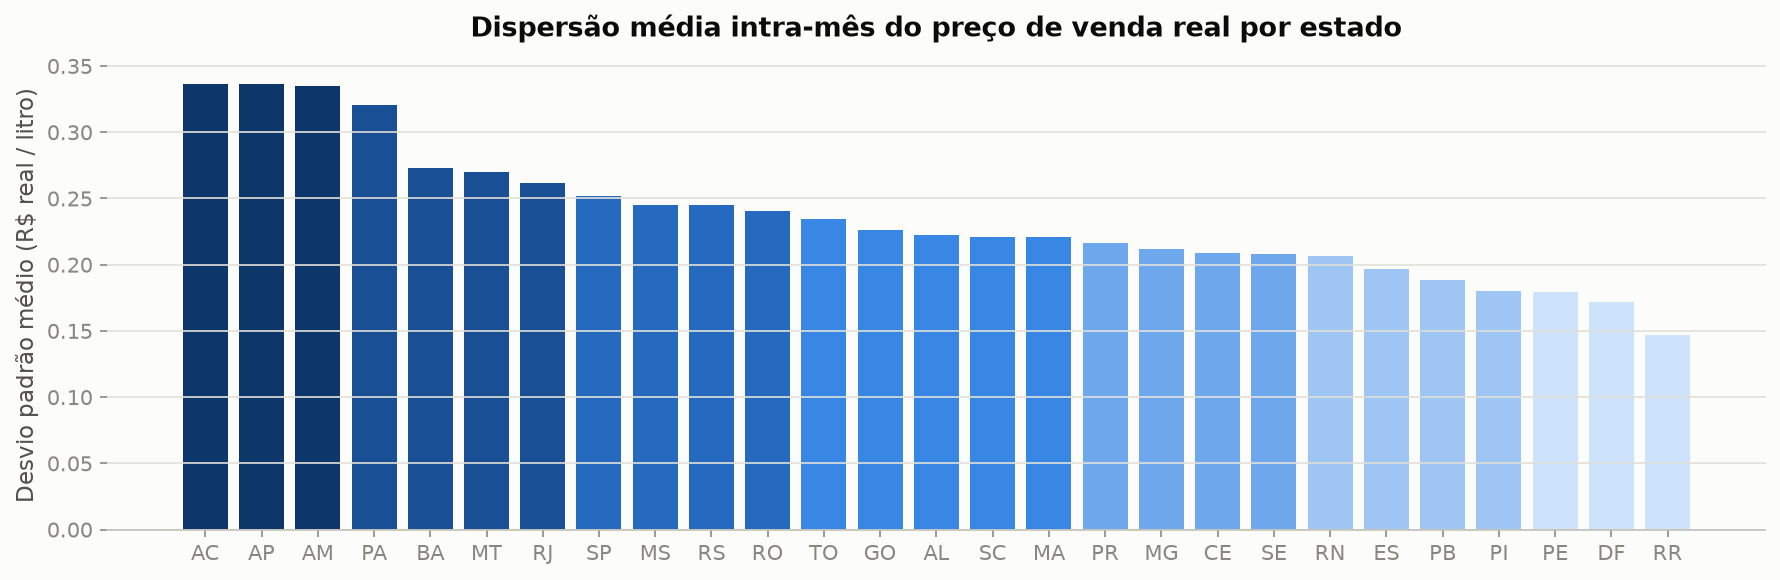

In [17]:
state_month_dispersion = duckdb.sql(f"""
    select
        estado_sigla as estado,
        date_trunc('month', data_da_coleta) as mes,
        stddev(valor_de_venda) as desvio_padrao_mes
    from df_data
    group by 1, 2
""").df()

state_dispersion = (
    state_month_dispersion
    .groupby("estado")["desvio_padrao_mes"]
    .mean()
    .sort_values(ascending=False)
)

fig, ax = plt.subplots(figsize=(12, 4))
ax.bar(state_dispersion.index, state_dispersion.values, color=sequential_by_rank(len(state_dispersion)))
ax.set_title("Dispersão média intra-mês do preço de venda real por estado")
ax.set_ylabel("Desvio padrão médio (R$ real / litro)")
plt.tight_layout()
plt.show()

O ranking de dispersão muda em relação ao nominal:

- **Real:** AC lidera (~R$0,34), seguido de perto por AP e AM (~R$0,33-0,34).
- **Nominal:** AM isolado na liderança (~R$0,22).
- **Mais homogêneo em ambos:** RR (~R$0,15 real vs ~R$0,08 nominal).

O padrão geral se mantém: "caro" (preço médio) e "instável/heterogêneo" (dispersão) continuam sendo dimensões diferentes. AC lidera as duas agora, mas RR (preço médio moderado) segue sendo o estado mais homogêneo — provavelmente por ter poucas revendas concentradas numa cadeia de suprimento única. Já AC/AP/AM, no Norte mais isolado geograficamente (rios, estradas precárias), formam mercados mais fragmentados com preços bem diferentes entre municípios no mesmo mês.

# Diferencial de preço entre variantes de diesel

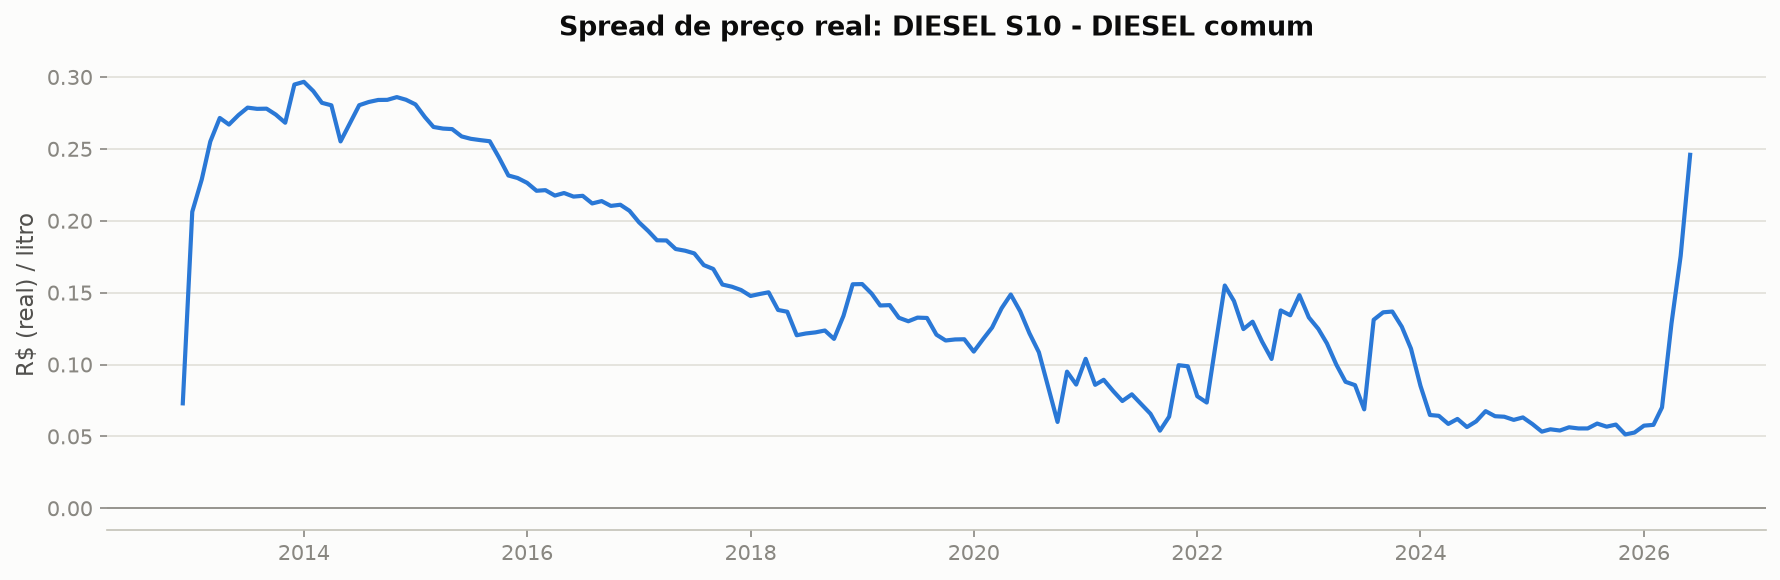

In [18]:
product_spread = monthly_price.pivot(index="mes", columns="produto", values="preco_medio")
product_spread["spread_s10_diesel"] = product_spread["DIESEL S10"] - product_spread["DIESEL"]

fig, ax = plt.subplots(figsize=(12, 4))
ax.plot(product_spread.index, product_spread["spread_s10_diesel"], color=PALETTE["categorical"][0])
ax.set_title("Spread de preço real: DIESEL S10 - DIESEL comum")
ax.set_ylabel("R$ (real) / litro")
ax.axhline(0, color=PALETTE["muted"], linewidth=0.8)
plt.tight_layout()
plt.show()

O spread real:

- **2013-2015:** ~R$0,20-0,30 (logo após a introdução em maior escala do S10).
- **2018-2025:** cai de forma consistente até um patamar médio de ~R$0,10 — mesma leitura do nominal, o S10 deixou de ser um produto "premium" de nicho e passou a competir de perto com o comum.
- **Fim de 2026:** salta para ~R$0,25, também presente no nominal.

Mas a explicação de "ruído de amostra pequena" do notebook nominal **não se sustenta**: checando o `n` de cada mês diretamente, jan-jun/2026 têm 7.000-14.000 coletas por mês — volume normal, não uma amostra pequena. Esse alargamento recente do spread parece ser um sinal real, não um artefato estatístico, e merece ser investigado (ex. mudança de composição tributária ou de custo específica do S10 em 2026) antes de ser descartado como ruído.

# Preço médio por bandeira (distribuidora)

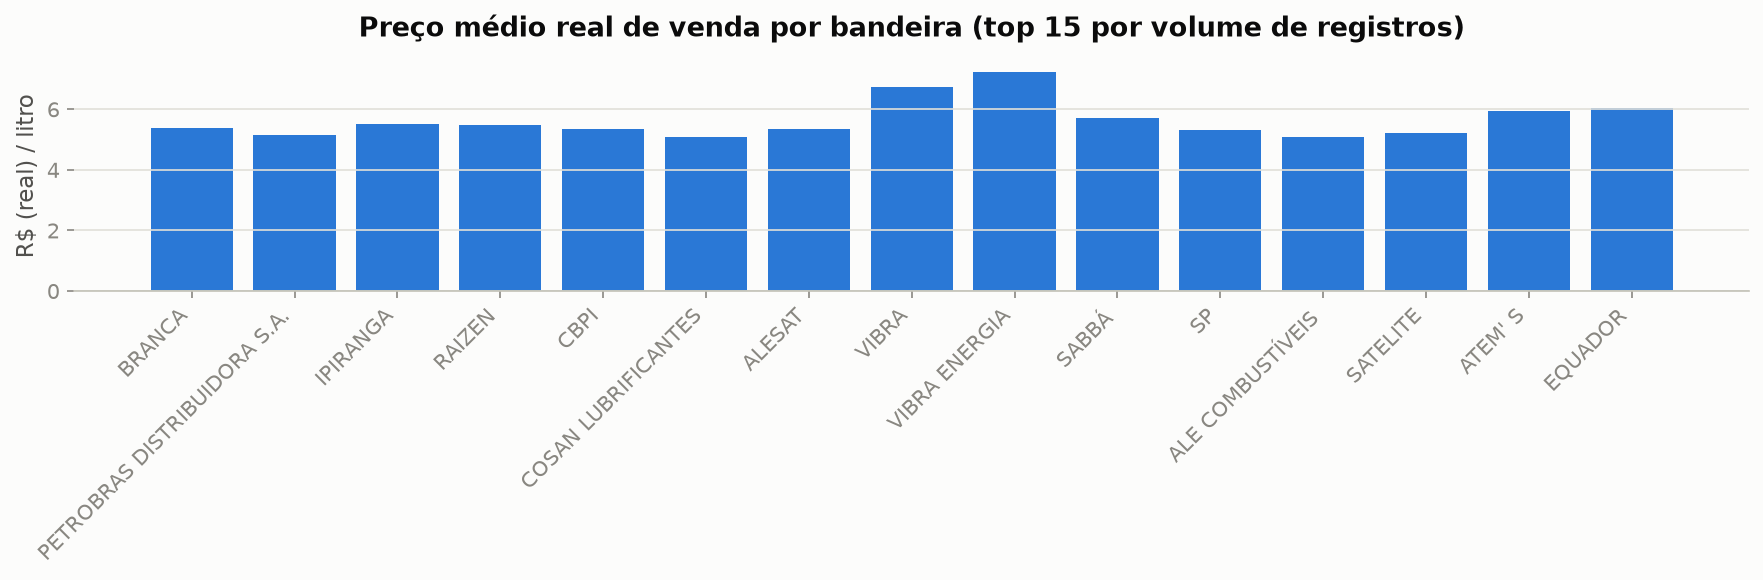

In [19]:
by_bandeira = duckdb.sql(f"""
    select
        coalesce(bandeira, '(nulo)') as bandeira,
        avg(valor_de_venda) as preco_medio,
        count(*) as n
    from df_data
    group by 1
    having count(*) >= 1000
    order by n desc
    limit 15
""").df()

fig, ax = plt.subplots(figsize=(12, 4))
ax.bar(by_bandeira["bandeira"], by_bandeira["preco_medio"], color=PALETTE["categorical"][0])
ax.set_title("Preço médio real de venda por bandeira (top 15 por volume de registros)")
ax.set_ylabel("R$ (real) / litro")
plt.xticks(rotation=45, ha="right")
plt.tight_layout()
plt.show()

**O viés de período reduz, mas não desaparece:**

- VIBRA e VIBRA ENERGIA continuam no topo (~R$6,74 e ~R$7,22).
- Razão sobre PETROBRAS DISTRIBUIDORA (~R$5,16, o nome antigo da mesma empresa antes do rebranding de 2021): **~1,4x** — contra quase **2x** na comparação nominal.

Isso confirma que boa parte do "preço alto da Vibra" era mesmo efeito de período (bandeira só existe nos anos recentes e caros em termos nominais). Mas sobra uma diferença real de ~R$1,60-2,00/litro que não se explica só por inflação — pode ser composição de clientes/postos que usam essa bandeira, ou um efeito real de posicionamento de preço da distribuidora nesse período recente.

Vale lembrar que essa comparação bruta ainda mistura bandeira com período (Vibra só aparece pós-2021, que é justamente o período do choque de preço real de 2021-2023) — uma comparação justa continuaria exigindo normalizar por mês.

# Sazonalidade - decomposição da série nacional mensal

2 mes(es) sem coleta - interpolando linearmente


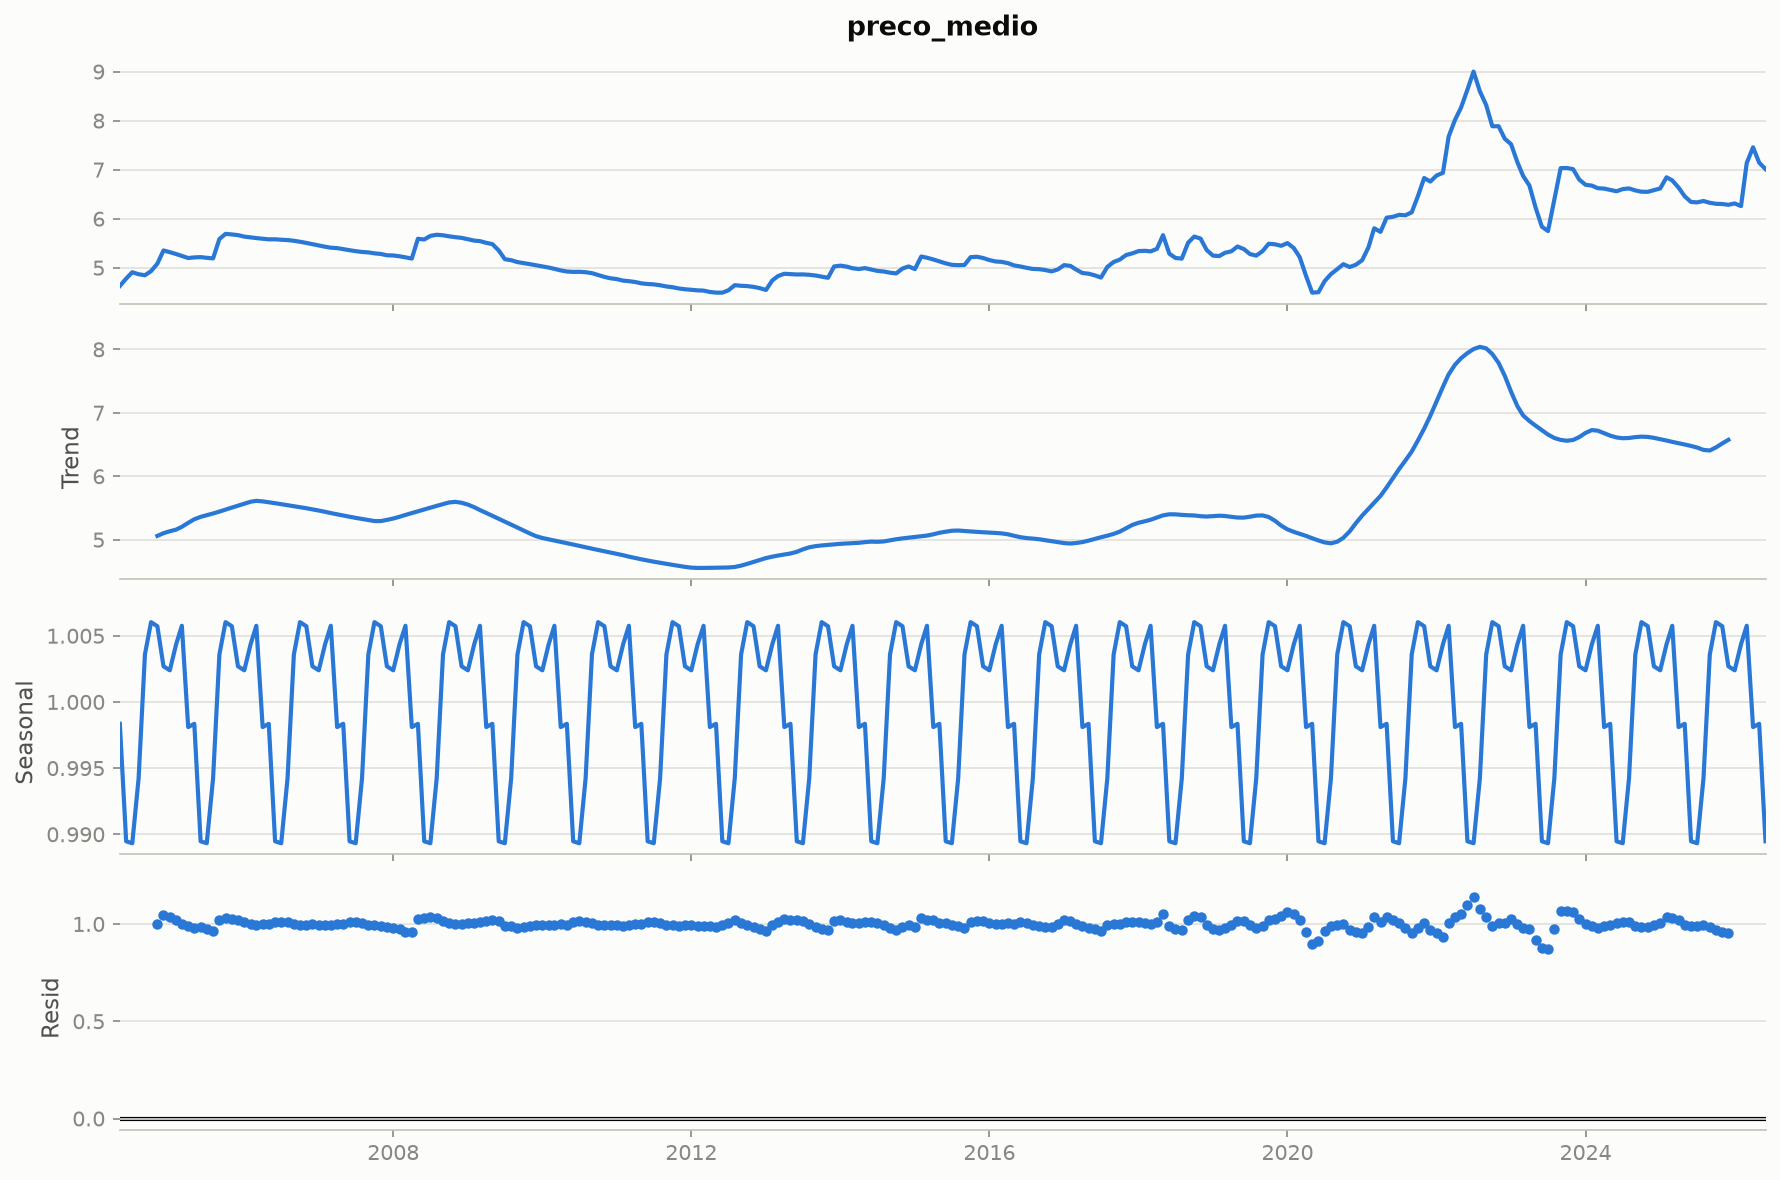

In [20]:
from statsmodels.tsa.seasonal import seasonal_decompose

national_monthly = duckdb.sql(f"""
    select
        date_trunc('month', data_da_coleta) as mes,
        avg(valor_de_venda) as preco_medio
    from df_data
    group by 1
    order by 1
""").df().set_index("mes")["preco_medio"].asfreq("MS")

n_faltantes = national_monthly.isna().sum()
if n_faltantes:
    print(f"{n_faltantes} mes(es) sem coleta - interpolando linearmente")
    national_monthly = national_monthly.interpolate(method="linear")

decomposition = seasonal_decompose(national_monthly, model="multiplicative", period=12)
fig = decomposition.plot()
fig.set_size_inches(12, 8)
for ax in fig.axes:
    ax.get_lines()[0].set_color(PALETTE["categorical"][0])
plt.tight_layout()
plt.show()

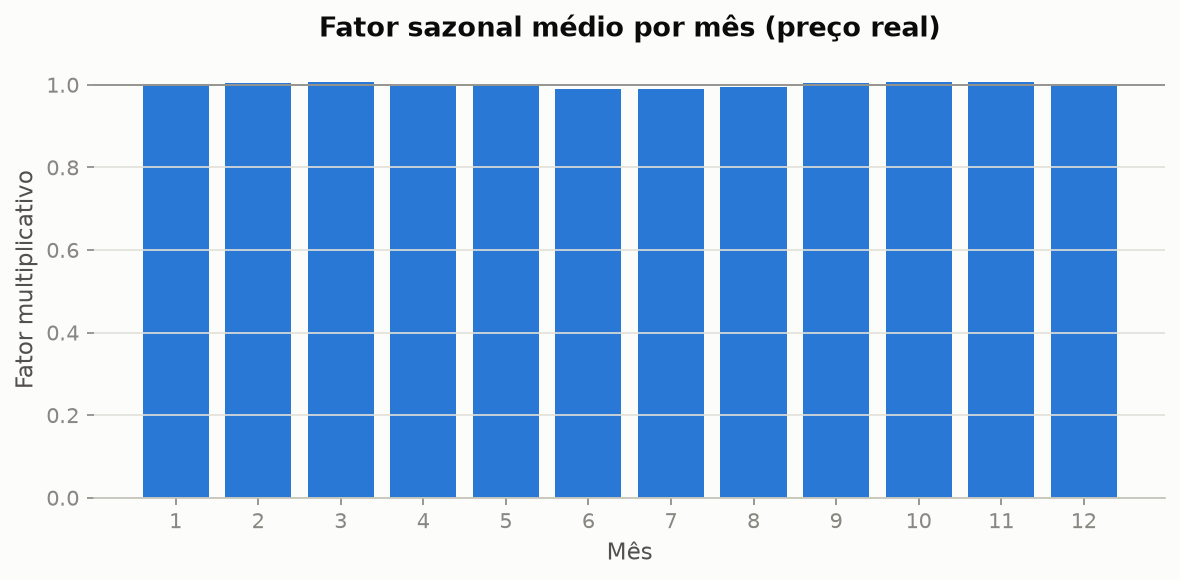

In [21]:
seasonal_by_month = decomposition.seasonal.groupby(decomposition.seasonal.index.month).mean()

fig, ax = plt.subplots(figsize=(8, 4))
ax.bar(seasonal_by_month.index, seasonal_by_month.values, color=PALETTE["categorical"][0])
ax.axhline(1.0, color=PALETTE["muted"], linewidth=0.8)
ax.set_title("Fator sazonal médio por mês (preço real)")
ax.set_ylabel("Fator multiplicativo")
ax.set_xlabel("Mês")
ax.set_xticks(range(1, 13))
plt.tight_layout()
plt.show()

## Robustez: STL, série completa vs. 2020+ vs. só pós-reforma do ICMS monofásico (2023+)

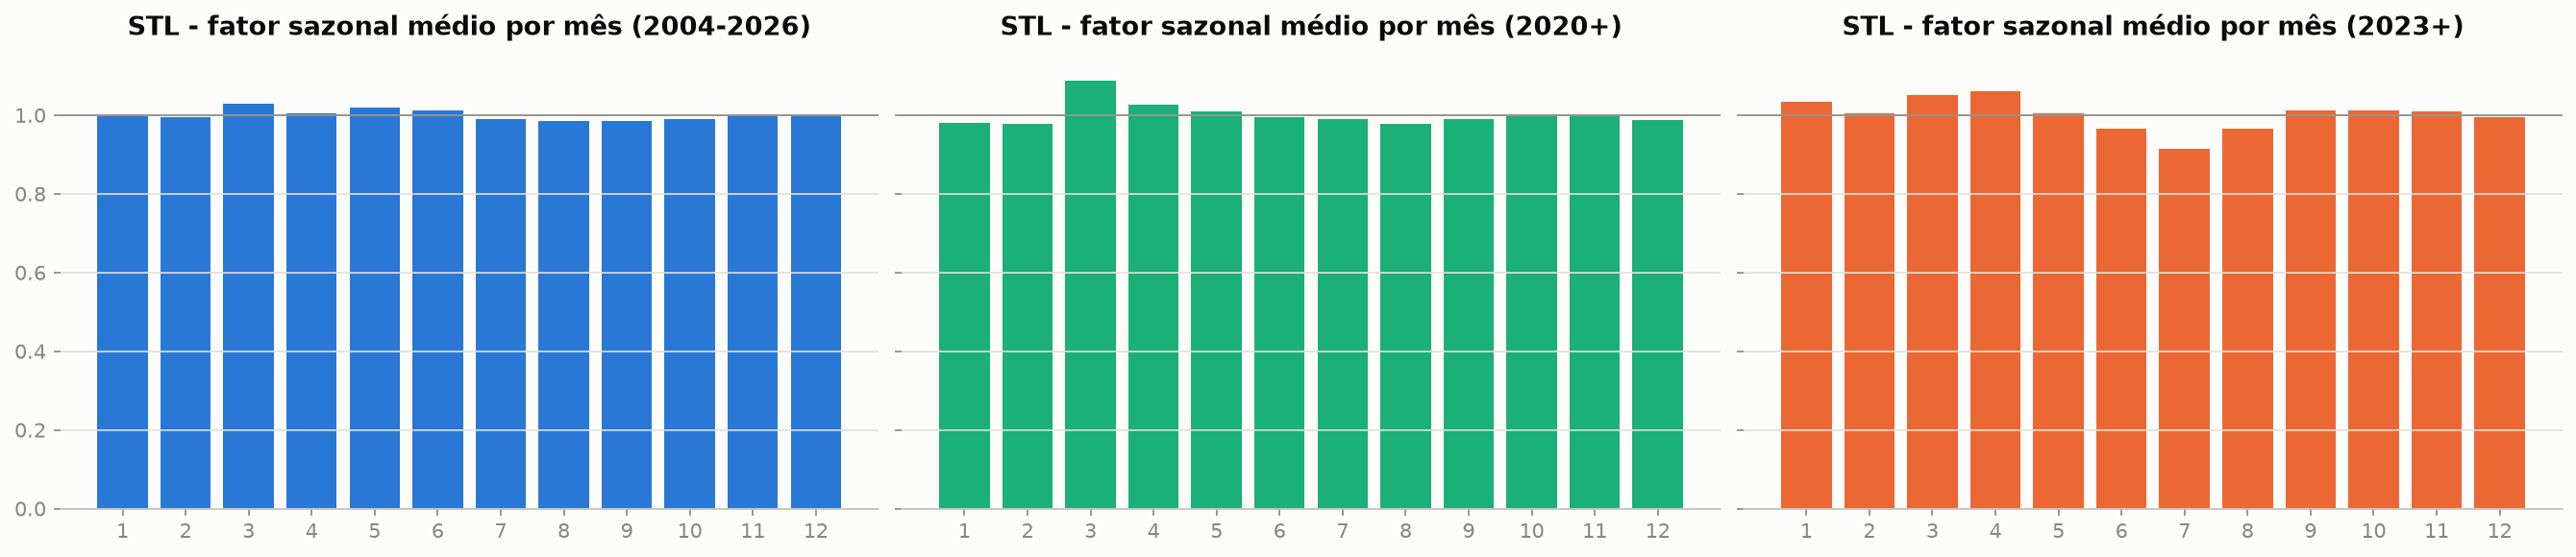

In [22]:
import numpy as np
from statsmodels.tsa.seasonal import STL

national_monthly_2020 = national_monthly["2020":]
national_monthly_recent = national_monthly["2023":]

stl_full = STL(np.log(national_monthly), period=12, robust=True).fit()
stl_2020 = STL(np.log(national_monthly_2020), period=12, robust=True).fit()
stl_recent = STL(np.log(national_monthly_recent), period=12, robust=True).fit()

seasonal_full_by_month = np.exp(stl_full.seasonal).groupby(stl_full.seasonal.index.month).mean()
seasonal_2020_by_month = np.exp(stl_2020.seasonal).groupby(stl_2020.seasonal.index.month).mean()
seasonal_recent_by_month = np.exp(stl_recent.seasonal).groupby(stl_recent.seasonal.index.month).mean()

fig, axes = plt.subplots(1, 3, figsize=(18, 4), sharey=True)

axes[0].bar(seasonal_full_by_month.index, seasonal_full_by_month.values, color=PALETTE["categorical"][0])
axes[0].axhline(1.0, color=PALETTE["muted"], linewidth=0.8)
axes[0].set_title("STL - fator sazonal médio por mês (2004-2026)")
axes[0].set_xticks(range(1, 13))

axes[1].bar(seasonal_2020_by_month.index, seasonal_2020_by_month.values, color=PALETTE["categorical"][2])
axes[1].axhline(1.0, color=PALETTE["muted"], linewidth=0.8)
axes[1].set_title("STL - fator sazonal médio por mês (2020+)")
axes[1].set_xticks(range(1, 13))

axes[2].bar(seasonal_recent_by_month.index, seasonal_recent_by_month.values, color=PALETTE["categorical"][1])
axes[2].axhline(1.0, color=PALETTE["muted"], linewidth=0.8)
axes[2].set_title("STL - fator sazonal médio por mês (2023+)")
axes[2].set_xticks(range(1, 13))

plt.tight_layout()
plt.show()

**Conclusão:** deflacionar não muda a conclusão qualitativa sobre sazonalidade — o padrão é pequeno mas real e robusto na direção, com pico no primeiro trimestre/início do segundo e vale em meados do ano, nas três janelas comparadas:

- Série completa (2004-2026): pico suave em **março** (fator 1,029), vale em **agosto-setembro** (~0,985).
- 2020+: pico bem mais agudo em **março** (fator 1,088), vale em **fevereiro/agosto** (~0,978).
- 2023+ (pós-reforma do ICMS monofásico): pico em **março-abril** (fator ~1,05-1,06), vale bem mais acentuado em **julho** (fator 0,915).

Como no notebook nominal, o 2020+ concentra o pico isoladamente em março (com poucos ciclos anuais, um valor atípico como março/2022 pesa desproporcionalmente), então para magnitude/forma do efeito eu confiaria mais no **2023+** — regime de precificação mais homogêneo e vale bem mais forte (~-8,5%) que nas outras duas janelas.

**Hipótese** (mantida): o pico no início do ano coincide com o pico da colheita da soja no Centro-Oeste (safra principal, jan-abr), quando a demanda por transporte de carga aumenta e pressiona o preço do diesel para cima. O vale em junho-agosto corresponde ao intervalo de menor movimento agrícola entre a safra principal e a safra de inverno.

**Relevância para o projeto:** o fato de a sazonalidade sobreviver quase intacta à deflação é um bom sinal — é um efeito real de mercado (calendário de safra), não um artefato de inflação sazonal do IPCA. Vale checar se um padrão semelhante (possivelmente defasado) aparece no preço real do feijão.

# Variação percentual mensal (MoM) e anual (YoY)

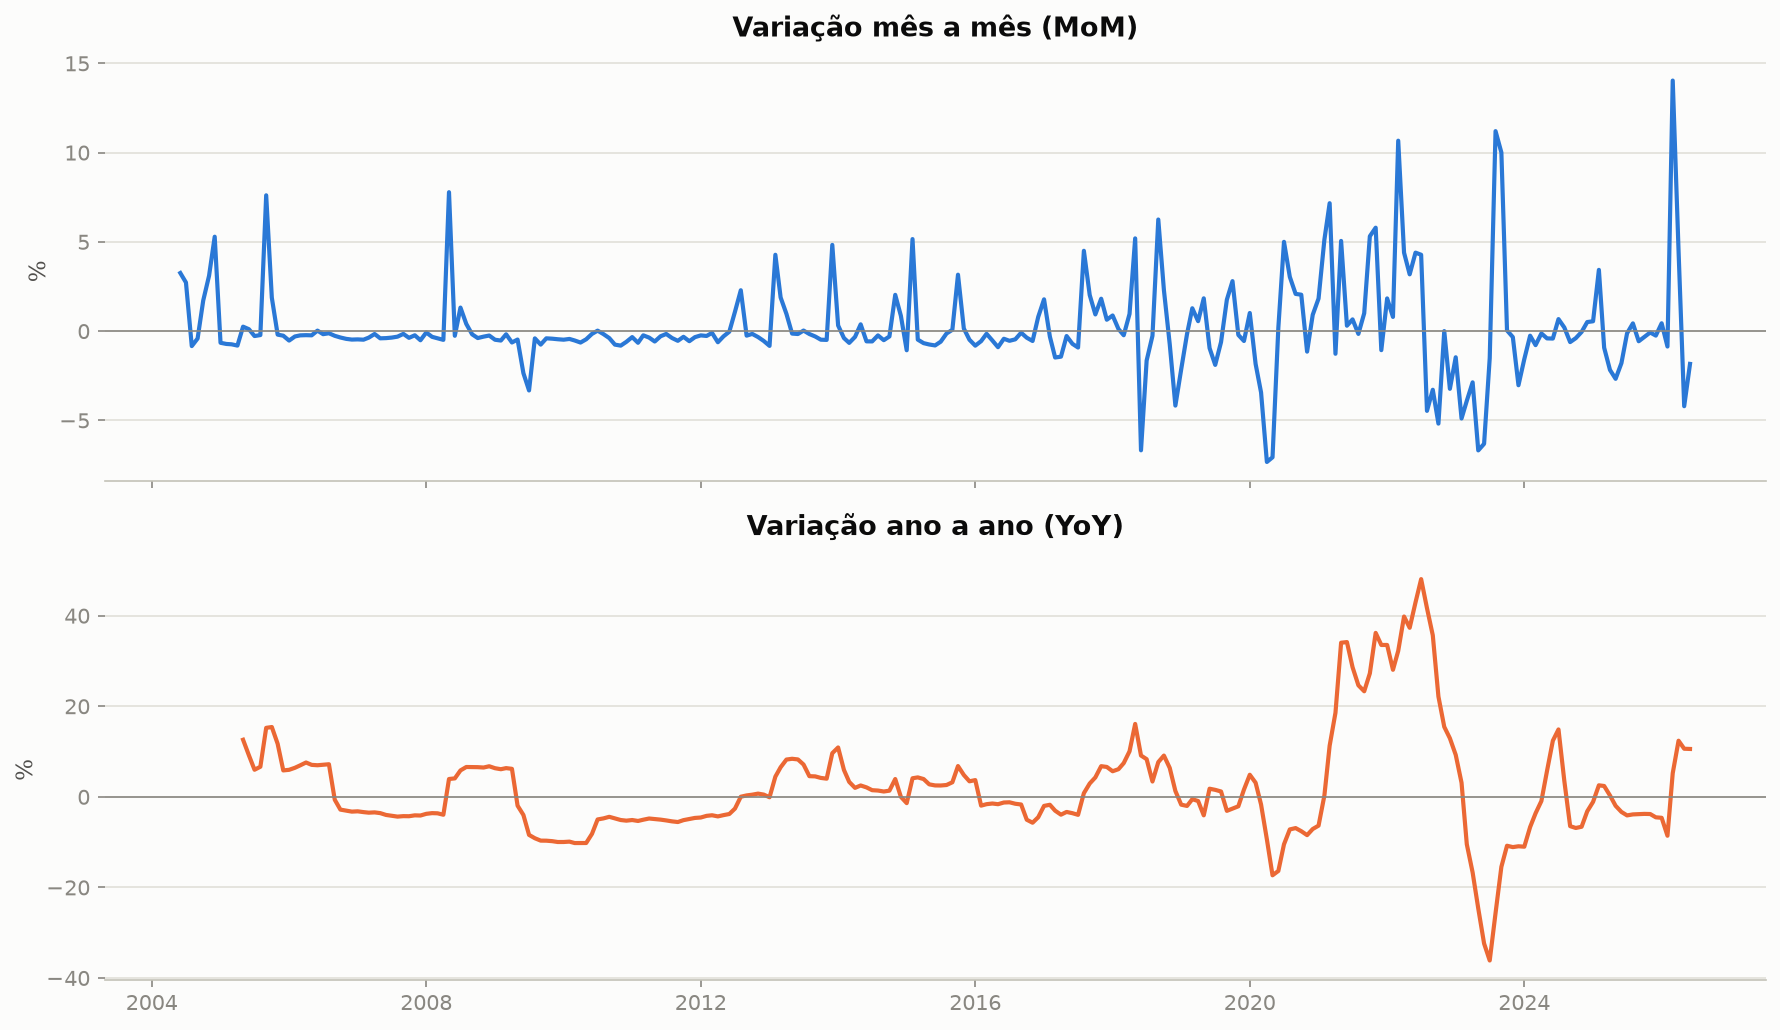

In [23]:
variacao = pd.DataFrame({
    "mom": national_monthly.pct_change(1) * 100,
    "yoy": national_monthly.pct_change(12) * 100,
})

fig, axes = plt.subplots(2, 1, figsize=(12, 7), sharex=True)

axes[0].plot(variacao.index, variacao["mom"], color=PALETTE["categorical"][0])
axes[0].axhline(0, color=PALETTE["muted"], linewidth=0.8)
axes[0].set_title("Variação mês a mês (MoM)")
axes[0].set_ylabel("%")

axes[1].plot(variacao.index, variacao["yoy"], color=PALETTE["categorical"][1])
axes[1].axhline(0, color=PALETTE["muted"], linewidth=0.8)
axes[1].set_title("Variação ano a ano (YoY)")
axes[1].set_ylabel("%")

plt.tight_layout()
plt.show()

O YoY real muda a magnitude dos três episódios em relação ao nominal — e numa direção que não é óbvia a priori:

- **Maio/2020 (COVID):** ~-17% real, bem menor que os ~-30% nominais — parte daquela queda nominal era só o real perdendo poder de compra menos rápido nesse período, não o diesel ficando "mais barato de verdade" na mesma proporção.
- **Julho/2022 (choque internacional/guerra na Ucrânia):** **+48%** real, menor que o +60% nominal.
- **Julho/2023 (reforma do ICMS monofásico):** **-36%** real, **mais acentuado** que o -30% nominal — nesse período a inflação geral (IPCA) continuava correndo enquanto o preço nominal do diesel caía, então em termos reais a queda foi ainda maior.

Ou seja, deflacionar não só muda a escala dos choques, pode inverter qual choque parece maior: no nominal, 2020 parecia comparável a 2023, mas em termos reais o colapso de 2023 é claramente o mais forte dos três.

Sobre o MoM: mesma leitura do nominal — os picos isolados de 2004-2010 (poucas coletas por mês nesse período inicial) são mais ruído de amostragem que sinal econômico; o YoY, suavizando numa janela de 12 meses, é mais confiável para esse trecho da série.

# Quebra estrutural formal (ruptures)

Até aqui os 3 regimes (paridade de importação 2016, congelamento 2021, reforma do ICMS monofásico 2022-2023) foram identificados só visualmente. Aqui usamos detecção formal de quebra estrutural (`ruptures`, algoritmo PELT com penalidade sobre o log do preço real nacional) para achar as datas de mudança de nível/tendência sem depender de hipótese prévia — e comparar com o que a leitura visual sugeriu.

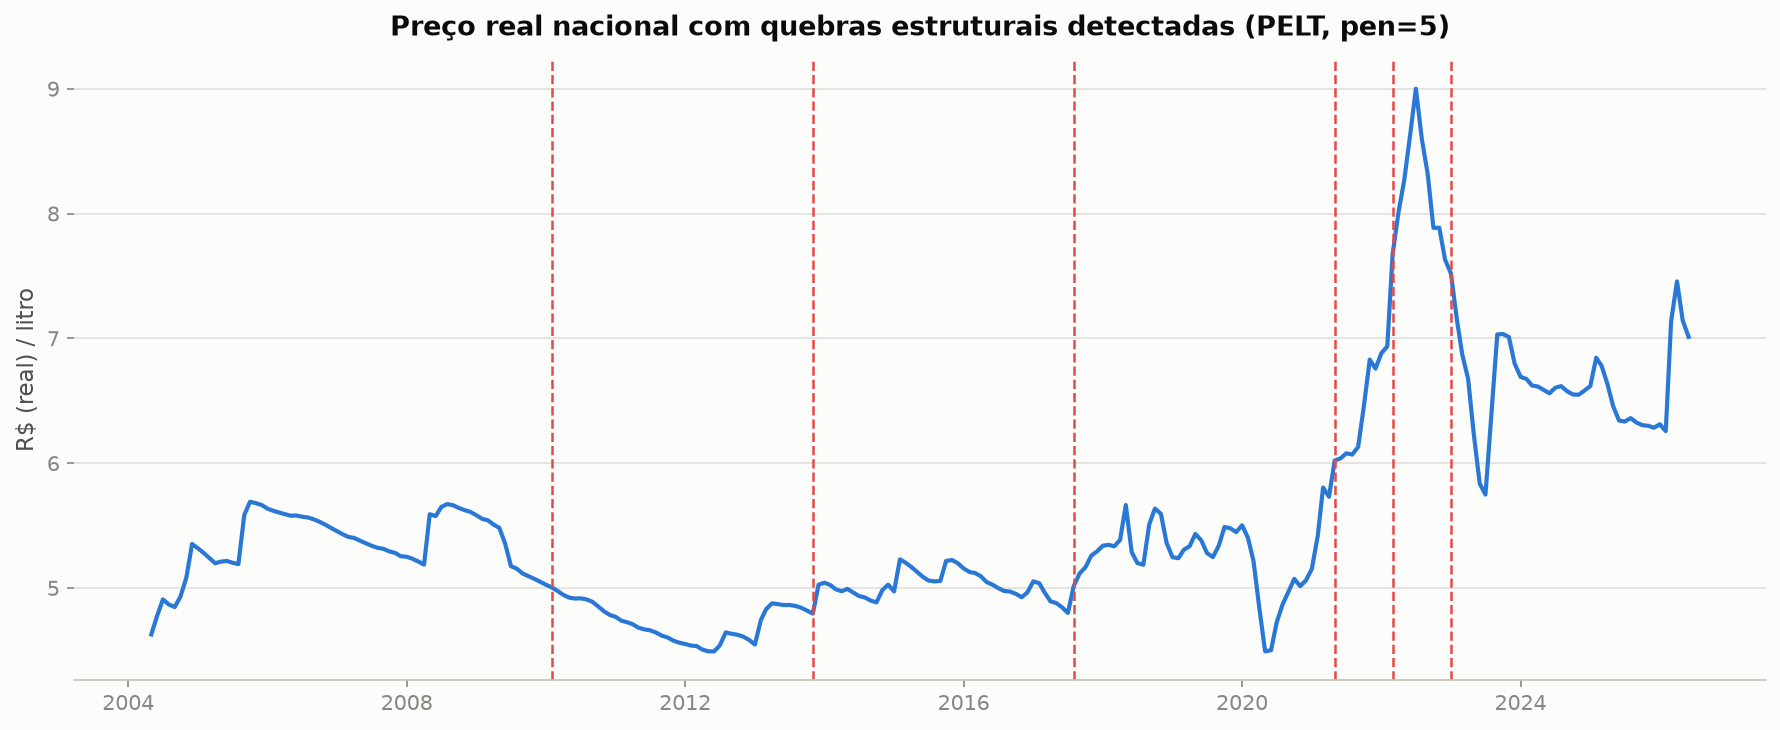

Datas de quebra detectadas: ['2010-02', '2013-11', '2017-08', '2021-05', '2022-03', '2023-01']


In [24]:
import ruptures as rpt

signal = np.log(national_monthly.values)

algo = rpt.Pelt(model="rbf").fit(signal)
breakpoints = algo.predict(pen=5)
breakpoints_dates = [national_monthly.index[i - 1] for i in breakpoints[:-1]]

fig, ax = plt.subplots(figsize=(12, 5))
ax.plot(national_monthly.index, national_monthly.values, color=PALETTE["categorical"][0])
for d in breakpoints_dates:
    ax.axvline(d, color=PALETTE["categorical"][7], linestyle="--", linewidth=1.2)
ax.set_title("Preço real nacional com quebras estruturais detectadas (PELT, pen=5)")
ax.set_ylabel("R$ (real) / litro")
plt.tight_layout()
plt.show()

print("Datas de quebra detectadas:", [d.strftime("%Y-%m") for d in breakpoints_dates])

O PELT encontra **6 quebras**: fev/2010, nov/2013, ago/2017, mai/2021, mar/2022, jan/2023.

Comparando com a hipótese visual dos 3 regimes:

- **Congelamento de preços (2021):** bate bem — quebra detectada em **mai/2021**.
- **Reforma do ICMS monofásico (2022-2023):** também bate — duas quebras próximas, **mar/2022** (início do choque internacional) e **jan/2023** (início da queda da reforma), capturando início e fim do episódio de alta volatilidade em vez de um único ponto.
- **Paridade de importação (2016):** não é confirmada como quebra isolada — o algoritmo aponta **ago/2017**, quase 2 anos depois do que a hipótese original sugeria. Em termos reais, o nível de preço não muda de forma abrupta em 2016; a mudança de regime de precificação parece ter levado mais tempo para se refletir no preço médio de mercado do que a mudança regulatória em si.

O método também acha **duas quebras não hipotetizadas antes**: fev/2010 e nov/2013 — ambas num período de aparente estabilidade no gráfico visual, sugerindo mudanças de nível mais sutis que passaram despercebidas na leitura qualitativa.

# Investigação: alargamento do spread S10 em 2026

No spread S10-DIESEL, vimos que o salto para ~R$0,25/litro no fim de 2026 não é explicado por amostra pequena (n normal). Duas hipóteses concorrentes: (1) é um efeito concentrado num estado/bandeira específico (ex. mudança tributária local), ou (2) é um efeito nacional, distribuído por todo o mercado. Comparamos o spread médio 2025 vs. 2026 por estado e por bandeira para distinguir as duas.

In [25]:
spread_by_state = duckdb.sql("""
    with by_state_prod as (
        select estado_sigla as estado, year(data_da_coleta) as ano, produto, avg(valor_de_venda) as p
        from df_data
        where produto in ('DIESEL', 'DIESEL S10') and year(data_da_coleta) in (2025, 2026)
        group by 1, 2, 3
    ), spreads as (
        select
            estado, ano,
            max(case when produto = 'DIESEL S10' then p end)
                - max(case when produto = 'DIESEL' then p end) as spread
        from by_state_prod
        group by 1, 2
    )
    select
        ano,
        avg(spread) as spread_medio,
        median(spread) as spread_mediano,
        sum(case when spread > 0 then 1 else 0 end) as n_estados_positivos,
        count(*) as n_estados
    from spreads
    group by 1
    order by 1
""").df()
spread_by_state

,ano,spread_medio,spread_mediano,n_estados_positivos,n_estados
0,2025,0.032169,0.06540,21.0,27
1,2026,0.083920,0.11408,22.0,27


In [26]:
spread_by_bandeira = duckdb.sql("""
    with by_band_prod as (
        select
            coalesce(bandeira, '(nulo)') as bandeira,
            year(data_da_coleta) as ano,
            produto,
            avg(valor_de_venda) as p,
            count(*) as n
        from df_data
        where produto in ('DIESEL', 'DIESEL S10') and year(data_da_coleta) in (2025, 2026)
        group by 1, 2, 3
    )
    select
        bandeira, ano,
        max(case when produto = 'DIESEL S10' then p end)
            - max(case when produto = 'DIESEL' then p end) as spread,
        sum(n) as n
    from by_band_prod
    group by 1, 2
    having sum(n) >= 500
    order by ano, spread desc
""").df()

pivot_bandeira = spread_by_bandeira.pivot(index="bandeira", columns="ano", values="spread").dropna()
pivot_bandeira["variacao"] = pivot_bandeira[2026] - pivot_bandeira[2025]
pivot_bandeira.sort_values("variacao", ascending=False)

ano,2025,2026,variacao
bandeira,,,
SABBÁ,-0.192954,0.017531,0.210485
RODOIL,0.025669,0.137232,0.111563
VIBRA,0.042365,0.137692,0.095327
CHARRUA,0.078596,0.172962,0.094366
IPIRANGA,0.097408,0.176601,0.079193
BRANCA,0.043827,0.108394,0.064567
ATEM' S,0.029127,0.087316,0.058189
RAIZEN,0.069077,0.121321,0.052244
ALE,0.086355,0.129274,0.042919


**Confirmado: efeito nacional, não concentrado.**

- **Por estado:** spread médio quase triplica (0,032 → 0,084) e o mediano quase dobra (0,065 → 0,114) de 2025 para 2026; **22 dos 27 estados** (vs. 21 em 2025) têm spread positivo — não é um ou dois estados puxando a média.
- **Por bandeira:** **todas** as bandeiras de volume relevante (≥500 coletas) sobem de 2025 para 2026, sem exceção — de RAIZEN/ALE (+~R$0,04-0,05) a SABBÁ/RODOIL (+~R$0,21/R$0,11, as maiores altas).

Isso descarta a hipótese de artefato local (uma bandeira ou estado específico). É consistente com uma mudança de custo ou tributação que afeta o S10 de forma ampla e simultânea em todo o país — candidatos prováveis incluem alteração na CIDE/PIS-COFINS específica do S10, mudança no mix de importação, ou reajuste da diferença de preço na refinaria entre as duas especificações. Não dá pra identificar a causa exata só com os dados da ANP; seria necessário cruzar com dados de tributação/refino (fora do escopo desta base).